In [1]:
# -----------------------------
# 05_calibration.ipynb — Full fixed calibration notebook (Option A, robust overflow handling)
# Paste the entire cell below
# -----------------------------
import os, json, math, random
from pathlib import Path
from typing import Dict, List, Tuple, Any

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.optim import LBFGS, Adam

from transformers import AutoTokenizer, AutoModelForSequenceClassification, BatchEncoding

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

# ----------------- CONFIG -----------------
DATA_SPLITS_ROOT = Path("/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/data_splits")
DISTILL_OUTPUT_ROOT = Path("/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/distillation")
CALIB_OUTPUT_ROOT = Path("/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/calibration")

STUDENT_MODEL_NAME_ID = "distil_distilbert-base-multilingual-cased"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ECE_BINS = 15
TEMPERATURE_INIT = 1.0
TEMPERATURE_LR = 0.01
TEMPERATURE_MAX_ITERS = 2000
USE_LBFGS = True

FIG_DPI = 150
SEED = 42

# reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ----------------- helpers -----------------
def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)
    return p

def read_label_map(lang_dir: Path) -> Tuple[Dict[str,int], Dict[int,str], Dict]:
    p = lang_dir / "label_map.json"
    if not p.exists():
        raise FileNotFoundError(f"label_map.json not found at {p}")
    jd = json.load(open(p, encoding="utf8"))
    label_map = {str(k): int(v) for k,v in jd.get("label_map", {}).items()}
    inv_label_map = {int(v): str(k) for k,v in jd.get("label_map", {}).items()}
    metadata = jd.get("metadata", {})
    return label_map, inv_label_map, metadata

def softmax_np(x: np.ndarray, axis=-1) -> np.ndarray:
    e = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e / (e.sum(axis=axis, keepdims=True) + 1e-12)

def nll_from_logits_and_labels(logits: np.ndarray, labels: np.ndarray) -> float:
    probs = softmax_np(logits, axis=1)
    probs = np.clip(probs, 1e-12, 1 - 1e-12)
    nll = -np.mean(np.log(probs[np.arange(len(labels)), labels]))
    return float(nll)

def brier_score(logits: np.ndarray, labels: np.ndarray) -> float:
    probs = softmax_np(logits, axis=1)
    n = len(labels)
    onehot = np.zeros_like(probs)
    onehot[np.arange(n), labels] = 1
    return float(np.mean(np.sum((probs - onehot)**2, axis=1)))

def expected_calibration_error(probs: np.ndarray, labels: np.ndarray, n_bins:int = 15) -> float:
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        mask = (confidences > bins[i]) & (confidences <= bins[i+1])
        if np.sum(mask) == 0:
            continue
        acc_bin = accuracies[mask].mean()
        conf_bin = confidences[mask].mean()
        ece += (np.sum(mask) / len(labels)) * abs(acc_bin - conf_bin)
    return float(ece)

def class_wise_ece(probs: np.ndarray, labels: np.ndarray, n_bins:int = 15) -> Dict[int, float]:
    n_classes = probs.shape[1]
    ece_per_class = {}
    for cls in range(n_classes):
        confs = probs[:, cls]
        true = (labels == cls).astype(float)
        bins = np.linspace(0.0, 1.0, n_bins+1)
        ece_c = 0.0
        for i in range(n_bins):
            mask = (confs > bins[i]) & (confs <= bins[i+1])
            if np.sum(mask) == 0:
                continue
            acc_bin = true[mask].mean()
            conf_bin = confs[mask].mean()
            ece_c += (np.sum(mask) / len(labels)) * abs(acc_bin - conf_bin)
        ece_per_class[cls] = float(ece_c)
    return ece_per_class

def entropy_of_probs(probs: np.ndarray) -> float:
    ps = np.clip(probs, 1e-12, 1-1e-12)
    ent = -np.sum(ps * np.log(ps), axis=1)
    return float(np.mean(ent))

def plot_reliability_diagram(probs: np.ndarray, labels: np.ndarray, n_bins:int=15, title:str="Reliability diagram", outpath:Path=None):
    bins = np.linspace(0.0, 1.0, n_bins+1)
    centers = (bins[:-1] + bins[1:]) / 2.0
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(float)
    bin_acc = np.zeros(len(centers))
    for i in range(len(centers)):
        mask = (confidences > bins[i]) & (confidences <= bins[i+1])
        if np.sum(mask) == 0:
            bin_acc[i] = np.nan
        else:
            bin_acc[i] = accuracies[mask].mean()
    plt.figure(figsize=(6,6), dpi=FIG_DPI)
    width = 1.0/len(centers)
    plt.bar(centers, np.nan_to_num(bin_acc, 0.0), width=width*0.95, alpha=0.7, label="Accuracy")
    plt.plot([0,1],[0,1],'k--', label="Perfect calibration")
    plt.xlim(0,1); plt.ylim(0,1)
    plt.xlabel("Confidence"); plt.ylabel("Accuracy"); plt.title(title)
    plt.legend()
    if outpath:
        plt.savefig(outpath, bbox_inches='tight')
    plt.close()

def plot_class_reliability_onevsrest(probs: np.ndarray, labels: np.ndarray, cls:int, n_bins:int=15, title:str=None, outpath:Path=None):
    if title is None:
        title = f"Class {cls} reliability (one-vs-rest)"
    bins = np.linspace(0.0, 1.0, n_bins+1)
    centers = (bins[:-1] + bins[1:]) / 2.0
    confs = probs[:, cls]
    true = (labels == cls).astype(float)
    bin_acc = np.zeros(len(centers))
    for i in range(len(centers)):
        mask = (confs > bins[i]) & (confs <= bins[i+1])
        if np.sum(mask) == 0:
            bin_acc[i] = np.nan
        else:
            bin_acc[i] = true[mask].mean()
    plt.figure(figsize=(6,6), dpi=FIG_DPI)
    plt.bar(centers, np.nan_to_num(bin_acc, 0.0), width=(1.0/len(centers))*0.95, alpha=0.7)
    plt.plot([0,1],[0,1],'k--')
    plt.xlim(0,1); plt.ylim(0,1)
    plt.xlabel("Confidence for class"); plt.ylabel("Empirical frequency of class"); plt.title(title)
    if outpath:
        plt.savefig(outpath, bbox_inches='tight')
    plt.close()

# Temperature scaler
class TemperatureScaler(nn.Module):
    def __init__(self, init_temp:float=1.0):
        super().__init__()
        self.log_t = nn.Parameter(torch.tensor(math.log(init_temp), dtype=torch.float32))
    def forward(self, logits: torch.Tensor) -> torch.Tensor:
        t = torch.exp(self.log_t)
        return logits / t
    def temperature(self):
        return float(torch.exp(self.log_t).detach().cpu().numpy())

def fit_temperature(logits: np.ndarray, labels: np.ndarray, device:torch.device, use_lbfgs:bool=True, max_iters:int=2000, lr:float=1e-2) -> Tuple[float, TemperatureScaler]:
    model = TemperatureScaler(init_temp=TEMPERATURE_INIT).to(device)
    logits_torch = torch.tensor(logits, dtype=torch.float32, device=device)
    labels_torch = torch.tensor(labels, dtype=torch.long, device=device)
    nll_criterion = nn.CrossEntropyLoss()
    if use_lbfgs:
        optimizer = torch.optim.LBFGS([model.log_t], lr=lr, max_iter=max_iters)
        def closure():
            optimizer.zero_grad()
            scaled = model(logits_torch)
            loss = nll_criterion(scaled, labels_torch)
            loss.backward()
            return loss
        optimizer.step(closure)
    else:
        optimizer = Adam([model.log_t], lr=lr)
        for i in range(max_iters):
            optimizer.zero_grad()
            scaled = model(logits_torch)
            loss = nll_criterion(scaled, labels_torch)
            loss.backward()
            optimizer.step()
    temp = model.temperature()
    return temp, model

# ----------------- Option A chunking (robust tokenizer overflow, no return_tensors) -----------------
def chunk_texts_tokenizer_overflow(tokenizer, texts: List[str], max_len:int, stride:int) -> List[List[Dict[str,Any]]]:
    """
    Use tokenizer overflow behavior but do NOT ask tokenizer to return tensors.
    Instead convert each chunk to a torch tensor individually (so varying lengths are OK).
    Returns list-of-lists of chunk dicts with 'input_ids' and 'attention_mask' (each is 1 x L tensor).
    """
    out = []
    for t in texts:
        enc: BatchEncoding = tokenizer(
            t,
            truncation=True,
            return_overflowing_tokens=True,
            max_length=max_len,
            stride=stride,
            return_offsets_mapping=False,
            return_tensors=None
        )
        # enc['input_ids'] is list-of-lists
        chunks = []
        if 'input_ids' not in enc:
            out.append([])
            continue
        input_ids_list = enc['input_ids']
        attn_list = enc.get('attention_mask', None)
        for i, ids in enumerate(input_ids_list):
            input_ids_tensor = torch.tensor(ids, dtype=torch.long).unsqueeze(0)
            if attn_list is not None:
                attn_tensor = torch.tensor(attn_list[i], dtype=torch.long).unsqueeze(0)
            else:
                attn_tensor = torch.ones_like(input_ids_tensor)
            chunks.append({"input_ids": input_ids_tensor, "attention_mask": attn_tensor})
        out.append(chunks)
    return out

def get_chunk_level_logits_for_docs_with_tokenizer(model, tokenizer, chunks_per_doc, batch_size=32):
    """
    Given chunks_per_doc produced by chunk_texts_tokenizer_overflow (each chunk is 1xL tensor),
    pad per-batch and run the model. Returns dict: doc_idx -> ndarray(num_chunks, num_labels)
    """
    model.eval()
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    out_map = {}
    for doc_idx in range(len(chunks_per_doc)):
        chunks = chunks_per_doc[doc_idx]
        if not chunks:
            out_map[doc_idx] = np.zeros((0, model.config.num_labels), dtype=float)
            continue
        logits_parts = []
        i = 0
        while i < len(chunks):
            batch_chunks = chunks[i:i+batch_size]
            batch_input_ids = [c['input_ids'].squeeze(0) for c in batch_chunks]
            batch_attention = [c['attention_mask'].squeeze(0) for c in batch_chunks]
            batch_input_ids_padded = torch.nn.utils.rnn.pad_sequence(batch_input_ids, batch_first=True, padding_value=pad_id).to(DEVICE)
            batch_attention_padded = torch.nn.utils.rnn.pad_sequence(batch_attention, batch_first=True, padding_value=0).to(DEVICE)
            with torch.no_grad():
                out = model(input_ids=batch_input_ids_padded, attention_mask=batch_attention_padded)
                logits = out.logits.detach().cpu().numpy()
            logits_parts.append(logits)
            i += batch_size
        out_map[doc_idx] = np.vstack(logits_parts)
    return out_map

# ----------------- MAIN calibration loop -----------------
LANGS = sorted([d.name for d in DATA_SPLITS_ROOT.iterdir() if d.is_dir()])
print("Languages detected:", LANGS)

for LANG in LANGS:
    print("\n" + "="*110)
    print("[LANG]", LANG)
    lang_dir = DATA_SPLITS_ROOT / LANG
    outdir = ensure_dir(CALIB_OUTPUT_ROOT / LANG / STUDENT_MODEL_NAME_ID)

    label_map, inv_label_map, metadata = read_label_map(lang_dir)
    num_labels = len(label_map)
    chunk_max_len = int(metadata.get("chunk_max_len", 256))
    chunk_stride = int(metadata.get("chunk_stride", 64))
    print(f"[INFO] label_map: {label_map} ; chunk_max_len={chunk_max_len} stride={chunk_stride}")

    student_model_dir = Path(DISTILL_OUTPUT_ROOT / LANG / STUDENT_MODEL_NAME_ID / "best_model")
    if not student_model_dir.exists():
        raise FileNotFoundError(f"Student best_model not found at {student_model_dir}. Run distillation first.")
    print(f"[INFO] Loading student from {student_model_dir}")
    tokenizer = AutoTokenizer.from_pretrained(str(student_model_dir), use_fast=True)
    student_model = AutoModelForSequenceClassification.from_pretrained(str(student_model_dir)).to(DEVICE)
    student_model.eval()

    df_val = pd.read_csv(lang_dir / "val.csv")
    df_test = pd.read_csv(lang_dir / "test.csv")

    def get_texts_and_labels(df):
        texts = []
        labels = []
        fps = []
        for _, r in df.iterrows():
            if 'text' in r and not pd.isna(r['text']):
                texts.append(str(r['text']))
            else:
                fp = str(r['file_path'])
                fps.append(fp)
                try:
                    texts.append(Path(fp).read_text(encoding="utf8", errors="ignore"))
                except Exception:
                    texts.append("")
            if 'label_id' in r and not pd.isna(r['label_id']):
                labels.append(int(r['label_id']))
            else:
                labels.append(int(label_map.get(str(r['label']), -1)))
        return texts, np.array(labels, dtype=int), fps

    val_texts, val_labels, val_fps = get_texts_and_labels(df_val)
    test_texts, test_labels, test_fps = get_texts_and_labels(df_test)

    print("[INFO] Chunking validation texts via tokenizer overflow ..")
    val_chunks_per_doc = chunk_texts_tokenizer_overflow(tokenizer, val_texts, max_len=chunk_max_len, stride=chunk_stride)
    print("[INFO] Chunking test texts via tokenizer overflow ..")
    test_chunks_per_doc = chunk_texts_tokenizer_overflow(tokenizer, test_texts, max_len=chunk_max_len, stride=chunk_stride)

    print("[INFO] Running student on validation chunks ...")
    val_chunk_logits_map = get_chunk_level_logits_for_docs_with_tokenizer(student_model, tokenizer, val_chunks_per_doc, batch_size=16)

    # Build val logits array aligned to df_val order
    val_logits_list = []
    for idx in range(len(val_fps)):
        arr = val_chunk_logits_map.get(idx, np.zeros((0, num_labels), dtype=float))
        agg = arr.mean(axis=0) if arr.shape[0] > 0 else np.zeros((num_labels,), dtype=float)
        val_logits_list.append(agg)
    val_logits_np = np.vstack(val_logits_list)

    print("[CALIB] Fit temperature on validation ...")
    temp, temp_model = fit_temperature(val_logits_np, val_labels, DEVICE, use_lbfgs=USE_LBFGS, max_iters=TEMPERATURE_MAX_ITERS, lr=TEMPERATURE_LR)
    print(f"[CALIB] Learned temperature T = {temp:.6f}")
    json.dump({"temperature": temp}, open(outdir / "temperature.json", "w", encoding="utf8"), indent=2)

    # Evaluate on validation
    val_logits_before = val_logits_np.copy()
    val_logits_after = val_logits_before / temp
    val_probs_before = softmax_np(val_logits_before, axis=1)
    val_probs_after = softmax_np(val_logits_after, axis=1)
    val_preds_before = val_probs_before.argmax(axis=1)
    val_preds_after = val_probs_after.argmax(axis=1)

    metrics_val = {}
    metrics_val['nll_before'] = nll_from_logits_and_labels(val_logits_before, val_labels)
    metrics_val['nll_after'] = nll_from_logits_and_labels(val_logits_after, val_labels)
    metrics_val['accuracy_before'] = float(accuracy_score(val_labels, val_preds_before))
    metrics_val['accuracy_after'] = float(accuracy_score(val_labels, val_preds_after))
    metrics_val['macro_f1_before'] = float(f1_score(val_labels, val_preds_before, average='macro', zero_division=0))
    metrics_val['macro_f1_after'] = float(f1_score(val_labels, val_preds_after, average='macro', zero_division=0))
    metrics_val['brier_before'] = brier_score(val_logits_before, val_labels)
    metrics_val['brier_after'] = brier_score(val_logits_after, val_labels)
    metrics_val['ece_before'] = expected_calibration_error(val_probs_before, val_labels, n_bins=ECE_BINS)
    metrics_val['ece_after'] = expected_calibration_error(val_probs_after, val_labels, n_bins=ECE_BINS)
    metrics_val['confusion_before'] = confusion_matrix(val_labels, val_preds_before).tolist()
    metrics_val['confusion_after'] = confusion_matrix(val_labels, val_preds_after).tolist()
    metrics_val['sharpness_before'] = entropy_of_probs(val_probs_before)
    metrics_val['sharpness_after'] = entropy_of_probs(val_probs_after)

    class_ece_val_before = class_wise_ece(val_probs_before, val_labels, n_bins=ECE_BINS)
    class_ece_val_after = class_wise_ece(val_probs_after, val_labels, n_bins=ECE_BINS)
    metrics_val['class_ece_before'] = class_ece_val_before
    metrics_val['class_ece_after'] = class_ece_val_after

    json.dump(metrics_val, open(outdir / "val_metrics_calibration.json", "w", encoding="utf8"), indent=2)
    plot_reliability_diagram(val_probs_before, val_labels, n_bins=ECE_BINS, title=f"{LANG} val reliability (before)", outpath=outdir / "val_reliability_before.png")
    plot_reliability_diagram(val_probs_after, val_labels, n_bins=ECE_BINS, title=f"{LANG} val reliability (after)", outpath=outdir / "val_reliability_after.png")

    for cls in range(num_labels):
        cls_name = inv_label_map.get(cls, str(cls))
        plot_class_reliability_onevsrest(val_probs_before, val_labels, cls, n_bins=ECE_BINS, title=f"{LANG} val class {cls_name} (before)", outpath=outdir / f"val_reliability_class_{cls}_{cls_name}_before.png")
        plot_class_reliability_onevsrest(val_probs_after, val_labels, cls, n_bins=ECE_BINS, title=f"{LANG} val class {cls_name} (after)", outpath=outdir / f"val_reliability_class_{cls}_{cls_name}_after.png")

    # ------------------ Test-time evaluation (prefer precomputed student logits) ------------------
    test_precomputed_npz = Path(DISTILL_OUTPUT_ROOT / LANG / STUDENT_MODEL_NAME_ID / "logits" / "student_test_chunk_logits.npz")
    if test_precomputed_npz.exists():
        print(f"[INFO] Loading precomputed student test chunk logits from {test_precomputed_npz}")
        loaded = np.load(str(test_precomputed_npz), allow_pickle=True)
        test_chunk_logits_map = {k: loaded[k] for k in loaded.files}
        test_file_logits_by_fp = {}
        for idx, fp in enumerate(test_fps):
            if fp in test_chunk_logits_map:
                arr = test_chunk_logits_map[fp]
            else:
                found_key = None
                for k in test_chunk_logits_map.keys():
                    if Path(k).name == Path(fp).name:
                        found_key = k; break
                if found_key:
                    arr = test_chunk_logits_map[found_key]
                else:
                    arr = None
            test_file_logits_by_fp[fp] = arr
    else:
        print("[INFO] No precomputed test chunk logits found; computing student logits on-the-fly for test set.")
        test_chunk_logits_map = None
        test_file_logits_by_fp = {}
        test_chunk_logits_map_by_idx = get_chunk_level_logits_for_docs_with_tokenizer(student_model, tokenizer, test_chunks_per_doc, batch_size=16)
        for idx in test_chunk_logits_map_by_idx:
            fp = test_fps[idx] if idx < len(test_fps) else str(idx)
            test_file_logits_by_fp[fp] = test_chunk_logits_map_by_idx[idx]

    # fill missing by computing from test_chunks_per_doc if any arr is None
    for idx, fp in enumerate(test_fps):
        if test_file_logits_by_fp.get(fp) is None:
            chunks = test_chunks_per_doc[idx]
            if not chunks:
                test_file_logits_by_fp[fp] = np.zeros((0, num_labels), dtype=float)
                continue
            logits_acc = []
            i = 0
            while i < len(chunks):
                batch_chunks = chunks[i:i+16]
                batch_input_ids = [c['input_ids'].squeeze(0) for c in batch_chunks]
                batch_attention = [c['attention_mask'].squeeze(0) for c in batch_chunks]
                pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
                batch_input_ids_padded = torch.nn.utils.rnn.pad_sequence(batch_input_ids, batch_first=True, padding_value=pad_id).to(DEVICE)
                batch_attention_padded = torch.nn.utils.rnn.pad_sequence(batch_attention, batch_first=True, padding_value=0).to(DEVICE)
                with torch.no_grad():
                    out = student_model(input_ids=batch_input_ids_padded, attention_mask=batch_attention_padded)
                    logits_acc.append(out.logits.detach().cpu().numpy())
                i += 16
            test_file_logits_by_fp[fp] = np.vstack(logits_acc)

    # aggregate test logits aligned to df_test order
    test_logits_list = []
    for idx, fp in enumerate(test_fps):
        arr = test_file_logits_by_fp.get(fp, np.zeros((0, num_labels), dtype=float))
        agg = arr.mean(axis=0) if arr.shape[0] > 0 else np.zeros((num_labels,), dtype=float)
        test_logits_list.append(agg)
    test_logits_np = np.vstack(test_logits_list)

    test_logits_before = test_logits_np.copy()
    test_logits_after = test_logits_before / temp
    test_probs_before = softmax_np(test_logits_before, axis=1)
    test_probs_after = softmax_np(test_logits_after, axis=1)
    test_preds_before = test_probs_before.argmax(axis=1)
    test_preds_after = test_probs_after.argmax(axis=1)

    metrics_test = {}
    metrics_test['nll_before'] = nll_from_logits_and_labels(test_logits_before, test_labels)
    metrics_test['nll_after'] = nll_from_logits_and_labels(test_logits_after, test_labels)
    metrics_test['accuracy_before'] = float(accuracy_score(test_labels, test_preds_before))
    metrics_test['accuracy_after'] = float(accuracy_score(test_labels, test_preds_after))
    metrics_test['macro_f1_before'] = float(f1_score(test_labels, test_preds_before, average='macro', zero_division=0))
    metrics_test['macro_f1_after'] = float(f1_score(test_labels, test_preds_after, average='macro', zero_division=0))
    metrics_test['brier_before'] = brier_score(test_logits_before, test_labels)
    metrics_test['brier_after'] = brier_score(test_logits_after, test_labels)
    metrics_test['ece_before'] = expected_calibration_error(test_probs_before, test_labels, n_bins=ECE_BINS)
    metrics_test['ece_after'] = expected_calibration_error(test_probs_after, test_labels, n_bins=ECE_BINS)
    metrics_test['confusion_before'] = confusion_matrix(test_labels, test_preds_before).tolist()
    metrics_test['confusion_after'] = confusion_matrix(test_labels, test_preds_after).tolist()
    metrics_test['sharpness_before'] = entropy_of_probs(test_probs_before)
    metrics_test['sharpness_after'] = entropy_of_probs(test_probs_after)

    class_ece_test_before = class_wise_ece(test_probs_before, test_labels, n_bins=ECE_BINS)
    class_ece_test_after = class_wise_ece(test_probs_after, test_labels, n_bins=ECE_BINS)
    metrics_test['class_ece_before'] = class_ece_test_before
    metrics_test['class_ece_after'] = class_ece_test_after

    # Save predictions CSV
    preds_rows = []
    for i, fp in enumerate(test_fps):
        preds_rows.append({
            "file_path": fp,
            "gold_label_id": int(test_labels[i]),
            "gold_label_str": inv_label_map.get(int(test_labels[i]), None),
            "pred_before_id": int(test_preds_before[i]),
            "pred_before_str": inv_label_map.get(int(test_preds_before[i]), None),
            "pred_after_id": int(test_preds_after[i]),
            "pred_after_str": inv_label_map.get(int(test_preds_after[i]), None),
            "prob_before": test_probs_before[i].tolist(),
            "prob_after": test_probs_after[i].tolist()
        })
    preds_df = pd.DataFrame(preds_rows)
    preds_csv_path = outdir / "predictions_calibrated.csv"
    preds_df.to_csv(preds_csv_path, index=False, encoding="utf8")

    json.dump(metrics_test, open(outdir / "metrics_test_calibrated.json", "w", encoding="utf8"), indent=2)
    json.dump(metrics_val, open(outdir / "metrics_val_calibrated.json", "w", encoding="utf8"), indent=2)

    plot_reliability_diagram(test_probs_before, test_labels, n_bins=ECE_BINS, title=f"{LANG} test reliability (before)", outpath=outdir / "test_reliability_before.png")
    plot_reliability_diagram(test_probs_after, test_labels, n_bins=ECE_BINS, title=f"{LANG} test reliability (after)", outpath=outdir / "test_reliability_after.png")

    ece_class_rows = []
    for cls in range(num_labels):
        cls_name = inv_label_map.get(cls, str(cls))
        out_png_before = outdir / f"test_reliability_class_{cls}_{cls_name}_before.png"
        out_png_after = outdir / f"test_reliability_class_{cls}_{cls_name}_after.png"
        plot_class_reliability_onevsrest(test_probs_before, test_labels, cls, n_bins=ECE_BINS, title=f"{LANG} test class {cls_name} (before)", outpath=out_png_before)
        plot_class_reliability_onevsrest(test_probs_after, test_labels, cls, n_bins=ECE_BINS, title=f"{LANG} test class {cls_name} (after)", outpath=out_png_after)
        ece_class_rows.append({
            "class_id": cls,
            "class_name": cls_name,
            "ece_before": class_ece_test_before.get(cls, None),
            "ece_after": class_ece_test_after.get(cls, None),
            "support": int((test_labels == cls).sum())
        })
    ece_class_df = pd.DataFrame(ece_class_rows)
    ece_class_df.to_csv(outdir / "ece_by_class.csv", index=False, encoding="utf8")

    summary = {
        "language": LANG,
        "student_model_dir": str(student_model_dir),
        "temperature": temp,
        "val_metrics": metrics_val,
        "test_metrics": metrics_test,
        "paths": {
            "predictions_csv": str(preds_csv_path.resolve()),
            "val_metrics_json": str((outdir / "val_metrics_calibration.json").resolve()),
            "metrics_test_calibrated": str((outdir / "metrics_test_calibrated.json").resolve()),
            "reliability_before": str((outdir / "test_reliability_before.png").resolve()),
            "reliability_after": str((outdir / "test_reliability_after.png").resolve()),
            "ece_by_class": str((outdir / "ece_by_class.csv").resolve())
        }
    }
    json.dump(summary, open(outdir / "summary.json", "w", encoding="utf8"), indent=2)
    print(f"[DONE] Calibration artifacts (Option A) saved under {outdir}")

print("\n[ALL DONE] Calibration finished for all languages (Option A).")


Languages detected: ['English', 'Hindi', 'Marathi']

[LANG] English
[INFO] label_map: {'G': 0, 'PG': 1, 'PG-13': 2, 'R': 3, 'NC-17': 4} ; chunk_max_len=256 stride=64
[INFO] Loading student from /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/distillation/English/distil_distilbert-base-multilingual-cased/best_model
[INFO] Chunking validation texts via tokenizer overflow ..
[INFO] Chunking test texts via tokenizer overflow ..
[INFO] Running student on validation chunks ...
[CALIB] Fit temperature on validation ...


/usr/local/lib/python3.12/dist-packages/torch/optim/lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  loss = float(closure())


[CALIB] Learned temperature T = 3.161957
[INFO] Loading precomputed student test chunk logits from /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/distillation/English/distil_distilbert-base-multilingual-cased/logits/student_test_chunk_logits.npz
[DONE] Calibration artifacts (Option A) saved under /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/calibration/English/distil_distilbert-base-multilingual-cased

[LANG] Hindi
[INFO] label_map: {'U': 0, 'UA': 1, 'A': 2} ; chunk_max_len=256 stride=64
[INFO] Loading student from /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/distillation/Hindi/distil_distilbert-base-multilingual-cased/best_model
[INFO] Chunking validation texts via tokenizer overflow ..
[INFO] Chunking test texts via tokenizer overflow ..
[INFO] Running student on validation chunks ...
[CALIB] Fit temperature on validation ...
[CALIB] Learned temperature T = 0.980274
[INFO] Loadin

In [1]:
import json, pandas as pd, numpy as np
from pathlib import Path
root = Path("/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/calibration")
for L in ["English","Hindi","Marathi"]:
    d = root / L / "distil_distilbert-base-multilingual-cased"
    print(L, "T=", json.load(open(d/"temperature.json"))["temperature"])
    print("test metrics:", json.load(open(d/"metrics_test_calibrated.json")))
    print("ece_by_class:\n", pd.read_csv(d/"ece_by_class.csv"))
    print("preds head:\n", pd.read_csv(d/"predictions_calibrated.csv").head(), "\n")


English T= 3.161956548690796
test metrics: {'nll_before': 1.641214370727539, 'nll_after': 0.9889562129974365, 'accuracy_before': 0.5813953488372093, 'accuracy_after': 0.5813953488372093, 'macro_f1_before': 0.5062214145085567, 'macro_f1_after': 0.5062214145085567, 'brier_before': 0.6846581101417542, 'brier_after': 0.5402637720108032, 'ece_before': 0.3030160069465637, 'ece_after': 0.08573221935089245, 'confusion_before': [[8, 1, 0, 0, 0], [1, 3, 3, 16, 0], [0, 2, 12, 30, 0], [0, 2, 13, 75, 0], [2, 0, 0, 2, 2]], 'confusion_after': [[8, 1, 0, 0, 0], [1, 3, 3, 16, 0], [0, 2, 12, 30, 0], [0, 2, 13, 75, 0], [2, 0, 0, 2, 2]], 'sharpness_before': 0.3007150888442993, 'sharpness_after': 1.0410652160644531, 'class_ece_before': {'0': 0.027823382307677853, '1': 0.13114437233483373, '2': 0.23615898032466942, '3': 0.28282158191554074, '4': 0.020077517100469056}, 'class_ece_after': {'0': 0.06605770638169244, '1': 0.035171428327123784, '2': 0.08887309225839239, '3': 0.119770277378171, '4': 0.04965817910

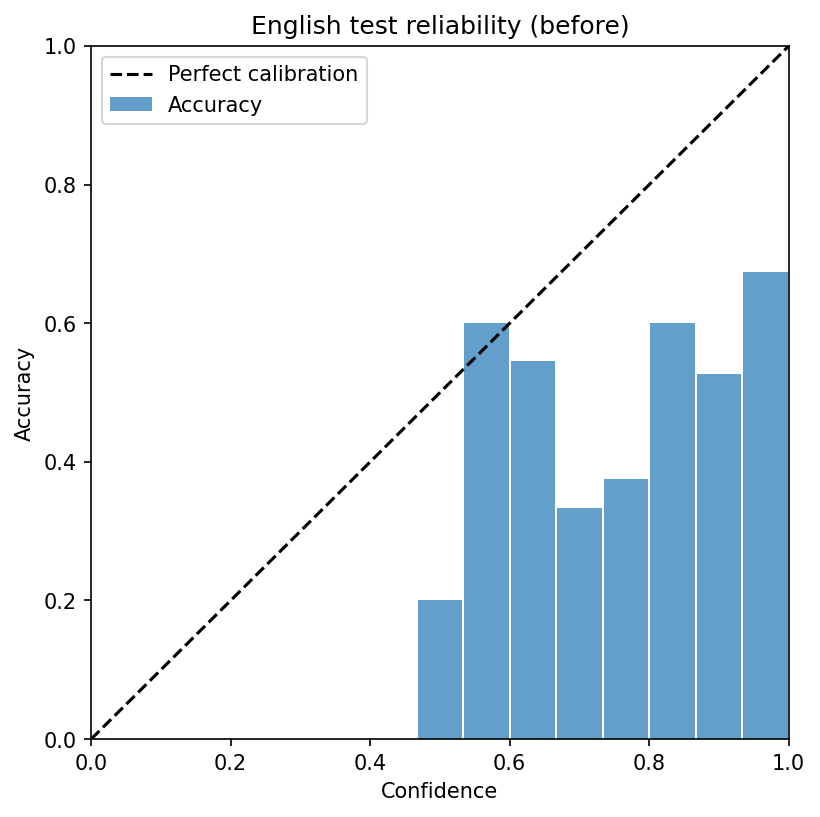

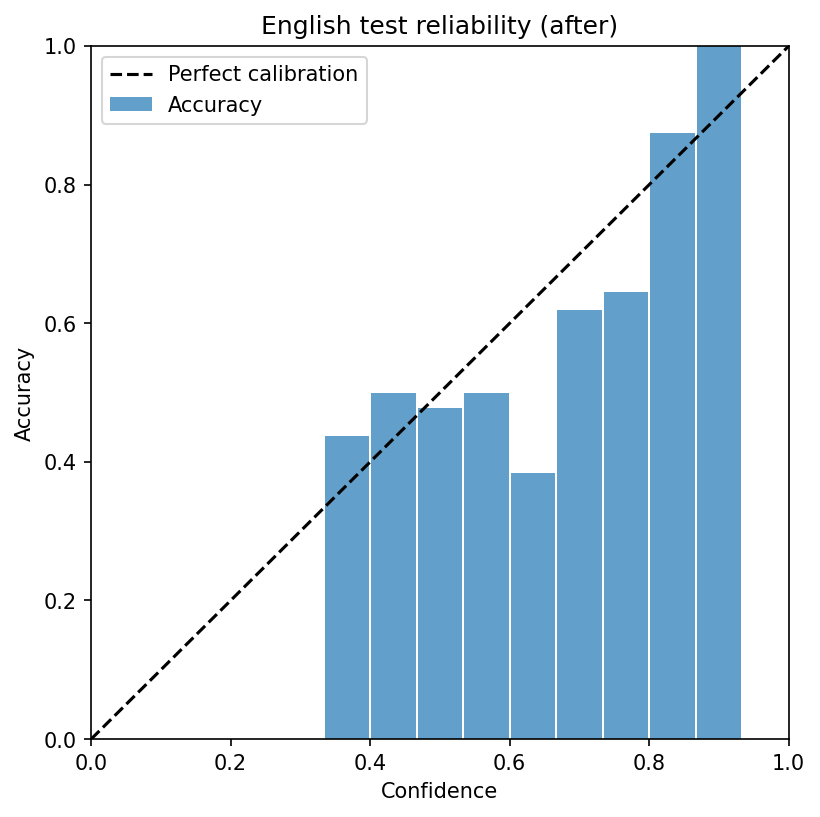

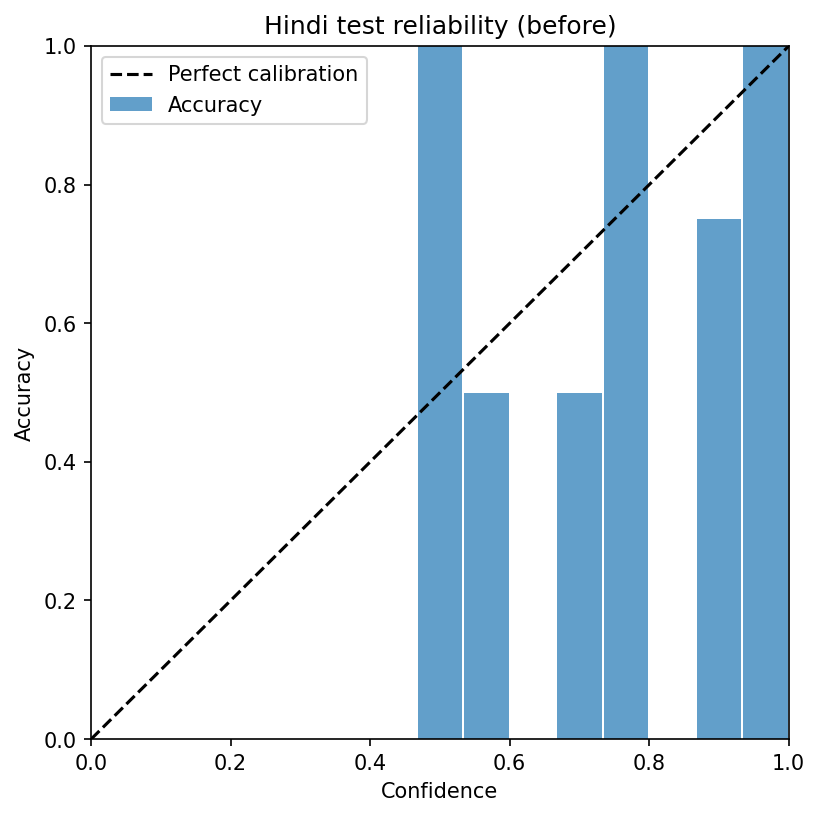

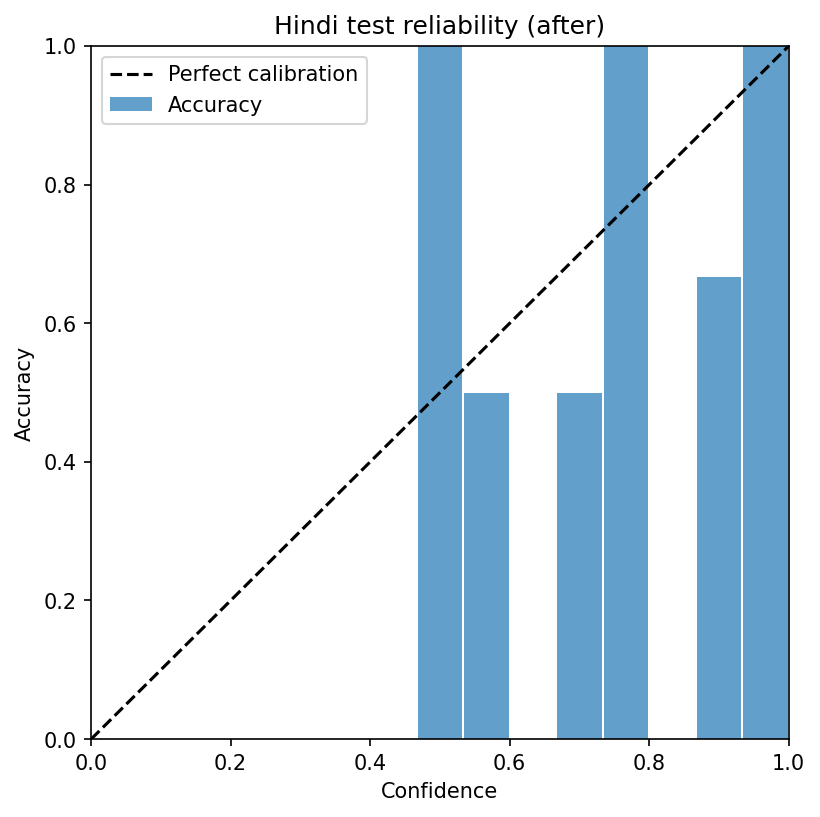

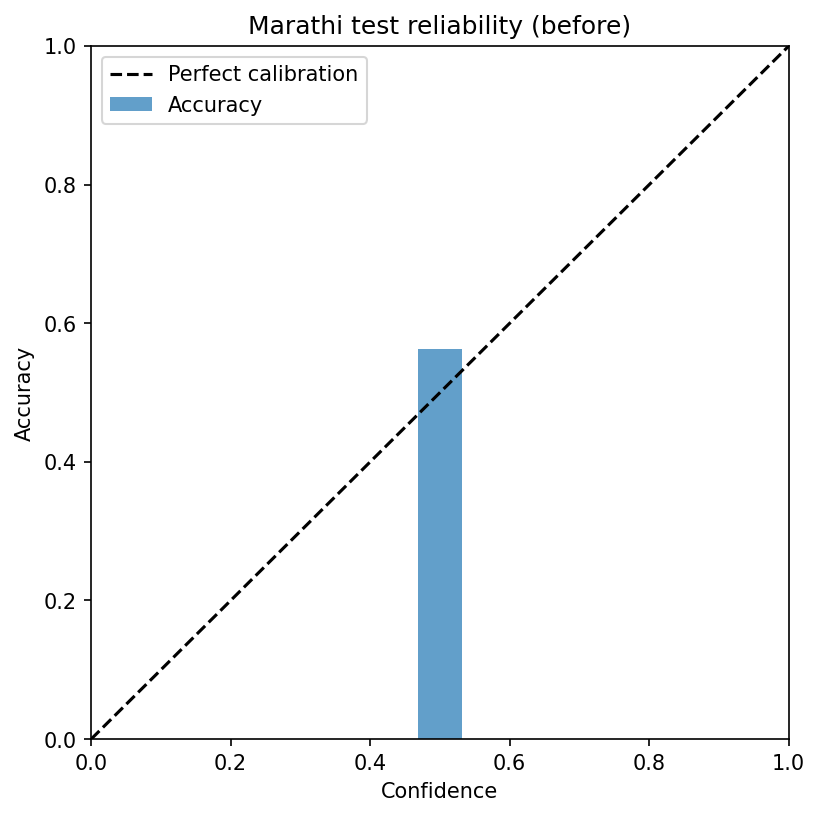

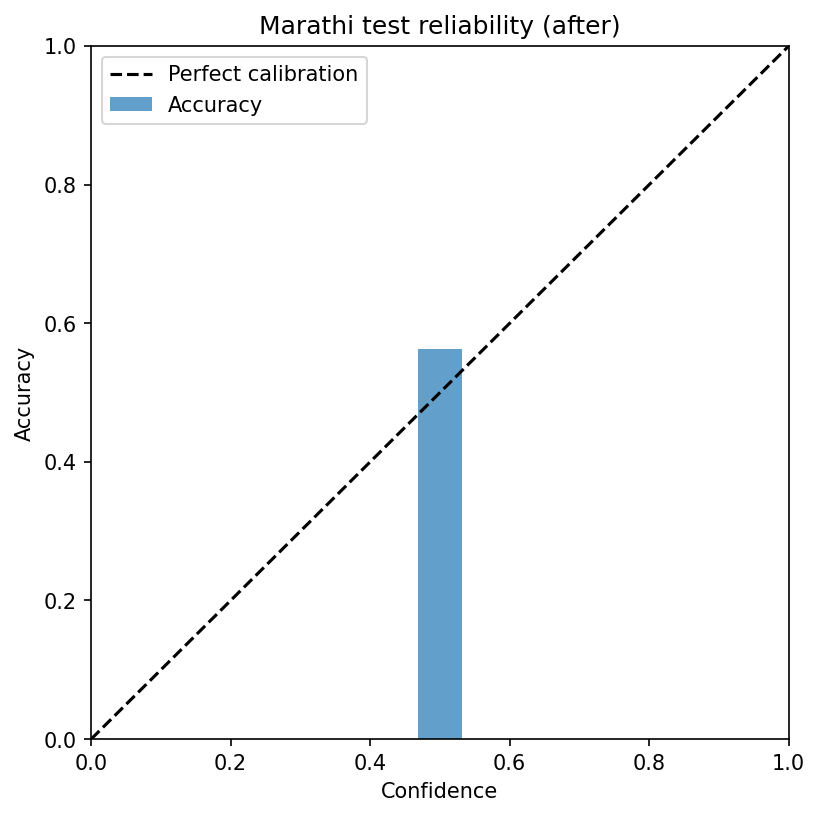

In [3]:
from IPython.display import Image, display
display(Image("/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/calibration/English/distil_distilbert-base-multilingual-cased/test_reliability_before.png"))
display(Image("/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/calibration/English/distil_distilbert-base-multilingual-cased/test_reliability_after.png"))

display(Image("/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/calibration/Hindi/distil_distilbert-base-multilingual-cased/test_reliability_before.png"))
display(Image("/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/calibration/Hindi/distil_distilbert-base-multilingual-cased/test_reliability_after.png"))

display(Image("/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/calibration/Marathi/distil_distilbert-base-multilingual-cased/test_reliability_before.png"))
display(Image("/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/calibration/Marathi/distil_distilbert-base-multilingual-cased/test_reliability_after.png"))


In [1]:
# -----------------------------
# Robust teacher_test_chunk_logits.npz generator (fixed tokenizer -> avoid return_tensors bug)
# Paste & run whole cell.
# -----------------------------
import json, os, time
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

ROOT = Path("/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2")
TRAIN_PIPELINE_OUT = ROOT / "outputs" / "train_pipeline"
DATA_SPLITS_ROOT = ROOT / "data_splits"
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

def chunk_texts(tokenizer, texts, max_len=256, stride=64):
    """
    Tokenize with overflow, truncation=True, but request raw Python lists (no tensors).
    For each text returns a list of chunk dicts containing torch tensors of shape (1, L).
    """
    out = []
    for t in texts:
        # request raw lists to avoid tokenizer.convert_to_tensors issues
        enc = tokenizer(
            t,
            truncation=True,
            return_overflowing_tokens=True,
            max_length=max_len,
            stride=stride,
            padding=False,
            return_tensors=None
        )
        # enc fields are lists of lists (input_ids, attention_mask)
        input_ids_list = enc.get("input_ids", [])
        attention_mask_list = enc.get("attention_mask", [])
        chunks = []
        for i in range(len(input_ids_list)):
            ids = torch.tensor(input_ids_list[i], dtype=torch.long).unsqueeze(0)
            mask = torch.tensor(attention_mask_list[i], dtype=torch.long).unsqueeze(0)
            chunks.append({"input_ids": ids, "attention_mask": mask})
        out.append(chunks)
    return out

def run_model_on_chunks(tokenizer, model, chunks_per_doc, batch_size=16, device=torch.device("cpu")):
    """
    Run model on chunks_per_doc (list-of-lists). Pads each batch to max length in that batch.
    Returns dict: doc_idx -> ndarray (n_chunks, C)
    """
    model.eval()
    logits_map = {}
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    for doc_idx in range(len(chunks_per_doc)):
        chunks = chunks_per_doc[doc_idx]
        if len(chunks) == 0:
            logits_map[doc_idx] = np.zeros((0, model.config.num_labels), dtype=float)
            continue
        logits_chunks = []
        i = 0
        while i < len(chunks):
            batch_chunks = chunks[i:i+batch_size]
            try:
                input_tensors = [c['input_ids'].squeeze(0) for c in batch_chunks]
                mask_tensors = [c['attention_mask'].squeeze(0) for c in batch_chunks]
                max_len_in_batch = max([t.size(0) for t in input_tensors])

                # safety: truncate if batch max exceeds model max positions
                model_max_pos = getattr(model.config, "n_positions", None) or getattr(model.config, "max_position_embeddings", None)
                if model_max_pos is not None and max_len_in_batch > model_max_pos:
                    input_tensors = [t[:model_max_pos] for t in input_tensors]
                    mask_tensors = [m[:model_max_pos] for m in mask_tensors]
                    max_len_in_batch = model_max_pos

                batch_input_ids = torch.nn.utils.rnn.pad_sequence(input_tensors, batch_first=True, padding_value=pad_id).to(device)
                batch_mask = torch.nn.utils.rnn.pad_sequence(mask_tensors, batch_first=True, padding_value=0).to(device)
                with torch.no_grad():
                    out = model(input_ids=batch_input_ids, attention_mask=batch_mask)
                    logits = out.logits.detach().cpu().numpy()
                logits_chunks.append(logits)
            except Exception as e:
                print(f"  [WARN] failed on doc {doc_idx} batch starting {i}: {e}. Falling back to per-chunk runs.")
                # fallback per-chunk
                for c in batch_chunks:
                    try:
                        inp = c['input_ids'].to(device)
                        msk = c['attention_mask'].to(device)
                        with torch.no_grad():
                            out = model(input_ids=inp, attention_mask=msk)
                            logits_chunks.append(out.logits.detach().cpu().numpy())
                    except Exception as e2:
                        print(f"    [WARN] per-chunk also failed: {e2}. Replacing with zeros for that chunk.")
                        logits_chunks.append(np.zeros((1, model.config.num_labels), dtype=float))
            i += batch_size
        # flatten and vstack
        flat = []
        for arr in logits_chunks:
            if arr.ndim == 2:
                flat.append(arr)
            elif arr.ndim == 3:
                # e.g. list of arrays
                for a in arr:
                    flat.append(a)
            else:
                # unexpected, skip
                pass
        if len(flat) == 0:
            logits_map[doc_idx] = np.zeros((0, model.config.num_labels), dtype=float)
        else:
            logits_map[doc_idx] = np.vstack(flat)
    return logits_map

# iterate languages & teacher dirs
langs = sorted([d.name for d in DATA_SPLITS_ROOT.iterdir() if d.is_dir()])
print("Languages detected:", langs)
summary = {}

for LANG in langs:
    print("\n" + "="*90)
    print("[LANG]", LANG)
    lang_dir = DATA_SPLITS_ROOT / LANG
    label_map_path = lang_dir / "label_map.json"
    if not label_map_path.exists():
        print(" - label_map.json missing; skipping", LANG)
        continue
    label_map = json.load(open(label_map_path, encoding="utf8"))
    metadata = label_map.get("metadata", {})
    chunk_max_len = int(metadata.get("chunk_max_len", 256))
    chunk_stride = int(metadata.get("chunk_stride", 64))
    print(f" - chunk params: max_len={chunk_max_len}, stride={chunk_stride}")

    test_csv = lang_dir / "test.csv"
    if not test_csv.exists():
        print(" - test.csv missing; skipping", LANG)
        continue
    df_test = pd.read_csv(test_csv)
    # read test texts
    test_texts = []
    file_paths = []
    for _, r in df_test.iterrows():
        fp = str(r['file_path'])
        file_paths.append(fp)
        try:
            text = Path(fp).read_text(encoding="utf8", errors="ignore")
        except Exception:
            text = ""
        test_texts.append(text)

    # find teacher experiment dir(s)
    train_lang_out = TRAIN_PIPELINE_OUT / LANG
    if not train_lang_out.exists():
        print(" - no train_pipeline outputs for", LANG)
        continue
    teacher_dirs = [d for d in train_lang_out.iterdir() if d.is_dir() and d.name.startswith("teacher_")]
    if not teacher_dirs:
        teacher_dirs = [d for d in train_lang_out.iterdir() if d.is_dir() and (d/"best_model").exists()]
    if not teacher_dirs:
        print(" - no teacher experiment dirs found under", train_lang_out)
        continue

    for teacher_dir in sorted(teacher_dirs):
        logits_dir = teacher_dir / "logits"
        logits_dir.mkdir(parents=True, exist_ok=True)
        npz_path = logits_dir / "teacher_test_chunk_logits.npz"
        mapping_path = logits_dir / "file_path_key_mapping.json"
        if npz_path.exists():
            print(f" - teacher_test_chunk_logits.npz already exists for {teacher_dir.name}; skipping generation.")
            loaded = np.load(str(npz_path), allow_pickle=True)
            summary.setdefault(LANG, []).append({"teacher_dir": str(teacher_dir), "npz_keys_sample": list(loaded.files)[:5], "npz_path": str(npz_path)})
            continue

        # locate teacher model
        best_model_dir = teacher_dir / "best_model"
        if not best_model_dir.exists():
            if (teacher_dir / "pytorch_model.bin").exists() or (teacher_dir / "config.json").exists():
                best_model_dir = teacher_dir
            else:
                print(f" - teacher model not found under {teacher_dir}; skipping this teacher_dir.")
                continue

        print(f" - loading teacher model/tokenizer from {best_model_dir} (may be slow)")
        try:
            tokenizer = AutoTokenizer.from_pretrained(str(best_model_dir), use_fast=True)
            model = AutoModelForSequenceClassification.from_pretrained(str(best_model_dir)).to(DEVICE)
            model.eval()
        except Exception as e:
            print(" - failed to load teacher model:", e)
            continue

        # chunk the test texts (safe truncation, raw lists -> tensors per chunk)
        print(" - chunking test texts via tokenizer overflow (truncation=True) ..")
        chunks_per_doc = chunk_texts(tokenizer, test_texts, max_len=chunk_max_len, stride=chunk_stride)

        # run teacher model on chunks
        print(" - running teacher on chunks .. (this may take a while)")
        logits_map_by_idx = run_model_on_chunks(tokenizer, model, chunks_per_doc, batch_size=BATCH_SIZE, device=DEVICE)

        # build mapping keys = absolute file paths
        npz_dict = {}
        for idx, fp in enumerate(file_paths):
            arr = logits_map_by_idx.get(idx)
            if arr is None:
                arr = np.zeros((0, model.config.num_labels), dtype=float)
            npz_dict[str(fp)] = arr

        # Save NPZ
        print(" - saving teacher_test_chunk_logits.npz to", npz_path)
        try:
            np.savez_compressed(str(npz_path), **npz_dict)
        except Exception as e:
            print(" - failed to save npz:", e)
            # try safer write
            np.savez_compressed(str(npz_path), **{k: v for k, v in npz_dict.items()})
        # Save mapping json
        mapping = {str(fp): str(fp) for fp in file_paths}
        with open(mapping_path, "w", encoding="utf8") as f:
            json.dump(mapping, f, indent=2)
        summary.setdefault(LANG, []).append({"teacher_dir": str(teacher_dir), "npz_path": str(npz_path), "n_files": len(file_paths)})
        print(f" - saved logits for {len(file_paths)} files under {npz_path}")

print("\nDone. Summary:")
print(json.dumps(summary, indent=2))
print("Now re-run the comparison table fill (the updater) to populate teacher metrics.")


Device: cuda
Languages detected: ['English', 'Hindi', 'Marathi']

[LANG] English
 - chunk params: max_len=256, stride=64
 - loading teacher model/tokenizer from /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/train_pipeline/English/teacher_distilbert-base-multilingual-cased/best_model (may be slow)
 - chunking test texts via tokenizer overflow (truncation=True) ..
 - running teacher on chunks .. (this may take a while)
 - saving teacher_test_chunk_logits.npz to /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/train_pipeline/English/teacher_distilbert-base-multilingual-cased/logits/teacher_test_chunk_logits.npz
 - saved logits for 172 files under /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/train_pipeline/English/teacher_distilbert-base-multilingual-cased/logits/teacher_test_chunk_logits.npz

[LANG] Hindi
 - chunk params: max_len=256, stride=64
 - loading teacher model/tokenizer from /co

In [4]:
# -----------------------------
# Generate comparison table: teacher vs student vs calibrated
# Corrected full cell — paste & run
# -----------------------------
import os, json, math
from pathlib import Path
from typing import Dict, Any, Tuple
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

# ---------- CONFIG ----------
ROOT = Path("/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2")
DATA_SPLITS_ROOT = ROOT / "data_splits"
TRAIN_PIPELINE_OUT = ROOT / "outputs" / "train_pipeline"
DISTILL_OUT = ROOT / "outputs" / "distillation"
CALIB_OUT = ROOT / "outputs" / "calibration"
ANALYSIS_OUT = ROOT / "outputs" / "analysis"
STUDENT_MODEL_ID = "distil_distilbert-base-multilingual-cased"
# ensure analysis dir
ANALYSIS_OUT.mkdir(parents=True, exist_ok=True)
ECE_BINS = 15
# --------------------------

def softmax_np(x: np.ndarray, axis=-1) -> np.ndarray:
    e = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e / (e.sum(axis=axis, keepdims=True) + 1e-12)

def nll_from_logits_and_labels(logits: np.ndarray, labels: np.ndarray) -> float:
    probs = softmax_np(logits, axis=1)
    probs = np.clip(probs, 1e-12, 1-1e-12)
    nll = -np.mean(np.log(probs[np.arange(len(labels)), labels]))
    return float(nll)

def brier_score(logits: np.ndarray, labels: np.ndarray) -> float:
    probs = softmax_np(logits, axis=1)
    n = len(labels)
    onehot = np.zeros_like(probs)
    onehot[np.arange(n), labels] = 1
    return float(np.mean(np.sum((probs - onehot)**2, axis=1)))

def expected_calibration_error(probs: np.ndarray, labels: np.ndarray, n_bins:int = 15) -> float:
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        mask = (confidences > bins[i]) & (confidences <= bins[i+1])
        if np.sum(mask) == 0:
            continue
        acc_bin = accuracies[mask].mean()
        conf_bin = confidences[mask].mean()
        ece += (np.sum(mask) / len(labels)) * abs(acc_bin - conf_bin)
    return float(ece)

def aggregate_chunk_logits_map_to_file_level(chunk_logits_map: Dict[str, np.ndarray]) -> Tuple[np.ndarray, list]:
    """
    chunk_logits_map: mapping file_path_or_key -> ndarray (n_chunks, C)
    returns: logits_np (N_files, C) aggregated by mean, and ordered list of file keys
    """
    keys = sorted(list(chunk_logits_map.keys()))
    agg_list = []
    for k in keys:
        arr = chunk_logits_map[k]
        if arr is None or (hasattr(arr, "shape") and arr.shape[0] == 0):
            # if arr exists but 0 rows, create zeros of shape (C,)
            if hasattr(arr, "shape") and len(arr.shape) == 2:
                agg = np.zeros((arr.shape[1],), dtype=float)
            else:
                agg = np.zeros((1,), dtype=float)
        else:
            agg = arr.mean(axis=0)
        agg_list.append(agg)
    return np.vstack(agg_list), keys

def load_label_map_and_test_labels(lang_dir: Path):
    lm_path = lang_dir / "label_map.json"
    if not lm_path.exists():
        raise FileNotFoundError(f"label_map.json missing at {lm_path}")
    lm = json.load(open(lm_path, encoding="utf8"))
    label_map = {str(k): int(v) for k,v in lm.get("label_map", {}).items()}
    inv_label_map = {int(v): str(k) for k,v in lm.get("label_map", {}).items()}
    test_csv = lang_dir / "test.csv"
    if not test_csv.exists():
        raise FileNotFoundError(f"test.csv missing at {test_csv}")
    df_test = pd.read_csv(test_csv)
    if 'label_id' in df_test.columns:
        labels = df_test['label_id'].astype(int).tolist()
    else:
        labels = [int(label_map.get(str(l), -1)) for l in df_test['label'].tolist()]
    file_paths = df_test['file_path'].astype(str).tolist() if 'file_path' in df_test.columns else [None]*len(df_test)
    return label_map, inv_label_map, file_paths, np.array(labels, dtype=int)

def compute_metrics_from_logits_and_labels(logits_np: np.ndarray, labels_np: np.ndarray):
    probs = softmax_np(logits_np, axis=1)
    preds = np.argmax(probs, axis=1)
    acc = float(accuracy_score(labels_np, preds))
    macro_f1 = float(f1_score(labels_np, preds, average="macro", zero_division=0))
    nll = nll_from_logits_and_labels(logits_np, labels_np)
    brier = brier_score(logits_np, labels_np)
    ece = expected_calibration_error(probs, labels_np, n_bins=ECE_BINS)
    return {"accuracy": acc, "macro_f1": macro_f1, "nll": nll, "brier": brier, "ece": ece, "n_samples": int(len(labels_np))}

def try_load_json_metrics(path: Path) -> Dict[str,Any]:
    if not path.exists(): return None
    try:
        return json.load(open(path, encoding="utf8"))
    except Exception:
        return None

# ---------- main loop across languages ----------
LANGS = sorted([d.name for d in DATA_SPLITS_ROOT.iterdir() if d.is_dir()])
rows = []
summary = {}
for LANG in LANGS:
    print("\n[LANG]", LANG)
    lang_dir = DATA_SPLITS_ROOT / LANG
    label_map, inv_label_map, file_paths_test, labels_test = load_label_map_and_test_labels(lang_dir)
    C = len(label_map)
    summary[LANG] = {}
    # 1) TEACHER metrics
    teacher_metrics = None
    train_lang_out = TRAIN_PIPELINE_OUT / LANG
    teacher_dirs = []
    if train_lang_out.exists():
        teacher_dirs = [d for d in train_lang_out.iterdir() if d.is_dir() and d.name.startswith("teacher_")]
        if not teacher_dirs:
            teacher_dirs = [d for d in train_lang_out.iterdir() if d.is_dir() and (d/"best_model").exists()]
    if teacher_dirs:
        teacher_dir = sorted(teacher_dirs)[-1]
        candidate_metrics = teacher_dir / "best_epoch_metrics.json"
        tmp = try_load_json_metrics(candidate_metrics)
        if tmp is None:
            candidate_metrics = teacher_dir / "metrics.json"
            tmp = try_load_json_metrics(candidate_metrics)
        if tmp:
            if "test_metrics" in tmp:
                teacher_metrics = tmp["test_metrics"]
            elif "val_metrics" in tmp:
                teacher_metrics = tmp["val_metrics"]
            else:
                teacher_metrics = {k: tmp[k] for k in ["accuracy","macro_f1","nll","brier","ece"] if k in tmp}
        logits_npz = teacher_dir / "logits" / "teacher_test_chunk_logits.npz"
        if teacher_metrics is None and logits_npz.exists():
            print(" - teacher metrics JSON not found; computing from teacher_test_chunk_logits.npz")
            loaded = np.load(str(logits_npz), allow_pickle=True)
            chunk_map = {k: loaded[k] for k in loaded.files}
            perfile = {}
            for i, fp in enumerate(file_paths_test):
                if fp in chunk_map:
                    perfile[fp] = chunk_map[fp]
                else:
                    found = None
                    for k in chunk_map.keys():
                        if Path(k).name == Path(fp).name:
                            found = k; break
                    perfile[fp] = chunk_map[found] if found else np.zeros((0,C), dtype=float)
            logits_np, keys = aggregate_chunk_logits_map_to_file_level(perfile)
            teacher_metrics = compute_metrics_from_logits_and_labels(logits_np, labels_test)
    else:
        print(" - no teacher experiment dir found for", LANG)
    if teacher_metrics is None:
        print(" - teacher metrics not found/computeable for", LANG)
    else:
        summary[LANG]['teacher'] = teacher_metrics

    # 2) STUDENT (distilled) uncalibrated metrics
    student_metrics = None
    # FIXED: student_dir must be a Path, not a concatenated string
    student_dir = DISTILL_OUT / LANG / STUDENT_MODEL_ID
    candidate = student_dir / "metrics.json"
    tmp = try_load_json_metrics(candidate)
    if tmp is not None:
        student_metrics = {k: tmp[k] for k in ["accuracy","macro_f1","nll","brier","ece"] if k in tmp}
    else:
        logits_npz = student_dir / "logits" / "student_test_chunk_logits.npz"
        if logits_npz.exists():
            print(" - student metrics JSON not found; computing from student_test_chunk_logits.npz")
            loaded = np.load(str(logits_npz), allow_pickle=True)
            chunk_map = {k: loaded[k] for k in loaded.files}
            perfile = {}
            for i, fp in enumerate(file_paths_test):
                if fp in chunk_map:
                    perfile[fp] = chunk_map[fp]
                else:
                    found=None
                    for k in chunk_map.keys():
                        if Path(k).name == Path(fp).name:
                            found = k; break
                    perfile[fp] = chunk_map[found] if found else np.zeros((0,C), dtype=float)
            logits_np, keys = aggregate_chunk_logits_map_to_file_level(perfile)
            student_metrics = compute_metrics_from_logits_and_labels(logits_np, labels_test)
    if student_metrics is None:
        print(" - student (distilled) metrics not found/computeable for", LANG)
    else:
        summary[LANG]['student'] = student_metrics

    # 3) STUDENT calibrated metrics (preferred saved file)
    calib_metrics = None
    candidate_calib = CALIB_OUT / LANG / STUDENT_MODEL_ID / "metrics_test_calibrated.json"
    tmp = try_load_json_metrics(candidate_calib)
    if tmp is not None:
        if "nll_after" in tmp:
            calib_metrics = {"nll": tmp["nll_after"], "accuracy": tmp["accuracy_after"], "macro_f1": tmp["macro_f1_after"], "brier": tmp.get("brier_after", None), "ece": tmp.get("ece_after", None)}
        elif "test_metrics" in tmp:
            tm = tmp["test_metrics"]
            calib_metrics = {k: tm.get(k, None) for k in ["accuracy","macro_f1","nll","brier","ece"]}
        else:
            if all(x in tmp for x in ["accuracy","macro_f1","nll","brier","ece"]):
                calib_metrics = {k: tmp[k] for k in ["accuracy","macro_f1","nll","brier","ece"]}
    if calib_metrics is None:
        preds_csv = CALIB_OUT / LANG / STUDENT_MODEL_ID / "predictions_calibrated.csv"
        if preds_csv.exists():
            try:
                dfp = pd.read_csv(preds_csv)
                probs = None
                if 'prob_after' in dfp.columns:
                    try:
                        probs = np.vstack(dfp['prob_after'].apply(lambda s: np.array(json.loads(s) if isinstance(s,str) else s)).values)
                    except Exception:
                        # sometimes pandas saved lists as strings differently; try eval
                        probs = np.vstack(dfp['prob_after'].apply(lambda s: np.array(eval(s)) if isinstance(s,str) else s).values)
                if probs is not None:
                    logits_approx = np.log(np.clip(probs, 1e-12, 1-1e-12))
                    gold = dfp['gold_label_id'].astype(int).to_numpy()
                    calib_metrics = compute_metrics_from_logits_and_labels(logits_approx, gold)
            except Exception as e:
                print(" - couldn't compute calibrated metrics from predictions CSV:", e)
        else:
            logits_npz = DISTILL_OUT / LANG / STUDENT_MODEL_ID / "logits" / "student_test_chunk_logits.npz"
            temp_path = CALIB_OUT / LANG / STUDENT_MODEL_ID / "temperature.json"
            if logits_npz.exists() and temp_path.exists():
                try:
                    loaded = np.load(str(logits_npz), allow_pickle=True)
                    chunk_map = {k: loaded[k] for k in loaded.files}
                    perfile = {}
                    for i, fp in enumerate(file_paths_test):
                        if fp in chunk_map:
                            perfile[fp] = chunk_map[fp]
                        else:
                            found=None
                            for k in chunk_map.keys():
                                if Path(k).name == Path(fp).name:
                                    found = k; break
                            perfile[fp] = chunk_map[found] if found else np.zeros((0,C), dtype=float)
                    logits_np, keys = aggregate_chunk_logits_map_to_file_level(perfile)
                    temp = json.load(open(temp_path, encoding="utf8")).get("temperature", 1.0)
                    logits_np_cal = logits_np / float(temp)
                    calib_metrics = compute_metrics_from_logits_and_labels(logits_np_cal, labels_test)
                except Exception as e:
                    print(" - failed to compute calibrated metrics from logits + temp:", e)
    if calib_metrics is None:
        print(" - calibrated metrics not found/computeable for", LANG)
    else:
        summary[LANG]['calibrated'] = calib_metrics

    # push a row for the table with available metrics
    def _g(mdict, key):
        return mdict.get(key, float("nan")) if mdict else float("nan")

    row = {
        "language": LANG,
        "teacher_accuracy": _g(teacher_metrics, "accuracy"),
        "teacher_macro_f1": _g(teacher_metrics, "macro_f1"),
        "teacher_nll": _g(teacher_metrics, "nll"),
        "teacher_brier": _g(teacher_metrics, "brier"),
        "teacher_ece": _g(teacher_metrics, "ece"),
        "student_accuracy": _g(student_metrics, "accuracy"),
        "student_macro_f1": _g(student_metrics, "macro_f1"),
        "student_nll": _g(student_metrics, "nll"),
        "student_brier": _g(student_metrics, "brier"),
        "student_ece": _g(student_metrics, "ece"),
        "calib_accuracy": _g(calib_metrics, "accuracy"),
        "calib_macro_f1": _g(calib_metrics, "macro_f1"),
        "calib_nll": _g(calib_metrics, "nll"),
        "calib_brier": _g(calib_metrics, "brier"),
        "calib_ece": _g(calib_metrics, "ece"),
        "n_test": int(labels_test.shape[0])
    }
    rows.append(row)

# create dataframe and save
df = pd.DataFrame(rows)
cf = ANALYSIS_OUT / "comparison_table.csv"
df.to_csv(cf, index=False, float_format="%.6f")
print("Saved comparison CSV to:", cf)

# also produce a LaTeX-ready table (simple)
def to_latex_table(df: pd.DataFrame, outpath: Path):
    cols = ["language",
            "teacher_accuracy","teacher_macro_f1","teacher_ece",
            "student_accuracy","student_macro_f1","student_ece",
            "calib_accuracy","calib_macro_f1","calib_ece",
            "n_test"]
    sub = df[cols].copy()
    for c in sub.columns:
        if c != "language":
            sub[c] = sub[c].apply(lambda x: ("{:.3f}".format(x) if pd.notna(x) else "--"))
    header = ("Language & "
              "Teacher (Acc / F1 / ECE) & "
              "Student (Acc / F1 / ECE) & "
              "Calib Student (Acc / F1 / ECE) & N_test \\\\ \\hline\n")
    rows_tex = []
    for _, r in sub.iterrows():
        t = "{} & {}/{}/{} & {}/{}/{} & {}/{}/{} & {} \\\\".format(
            r['language'],
            r['teacher_accuracy'], r['teacher_macro_f1'], r['teacher_ece'],
            r['student_accuracy'], r['student_macro_f1'], r['student_ece'],
            r['calib_accuracy'], r['calib_macro_f1'], r['calib_ece'],
            r['n_test']
        )
        rows_tex.append(t)
    table_tex = "\\begin{tabular}{l c c c c}\n" + header + "\n".join(rows_tex) + "\n\\end{tabular}\n"
    open(outpath, "w", encoding="utf8").write(table_tex)
    print("Saved LaTeX table to:", outpath)

latex_path = ANALYSIS_OUT / "comparison_table.tex"
to_latex_table(df, latex_path)

# Save full JSON summary
json_path = ANALYSIS_OUT / "comparison_summary.json"
json.dump(summary, open(json_path, "w", encoding="utf8"), indent=2)
print("Saved JSON summary to:", json_path)

print("\nDone. Files written under:", ANALYSIS_OUT)
print("If some entries are NaN, that indicates metrics were not found and couldn't be computed automatically; check the logs above.")



[LANG] English

[LANG] Hindi

[LANG] Marathi
Saved comparison CSV to: /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/analysis/comparison_table.csv
Saved LaTeX table to: /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/analysis/comparison_table.tex
Saved JSON summary to: /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/analysis/comparison_summary.json

Done. Files written under: /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/analysis
If some entries are NaN, that indicates metrics were not found and couldn't be computed automatically; check the logs above.


In [5]:
# -----------------------------
# Fill missing teacher/student metrics from saved chunk logits (safe updater)
# Paste & run whole cell
# -----------------------------
import json, math, os
from pathlib import Path
import numpy as np, pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
ROOT = Path("/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2")
ANALYSIS_OUT = ROOT / "outputs" / "analysis"
DATA_SPLITS_ROOT = ROOT / "data_splits"
TRAIN_PIPELINE_OUT = ROOT / "outputs" / "train_pipeline"
DISTILL_OUT = ROOT / "outputs" / "distillation"
CALIB_OUT = ROOT / "outputs" / "calibration"
STUDENT_MODEL_ID = "distil_distilbert-base-multilingual-cased"
ECE_BINS = 15

def softmax_np(x: np.ndarray, axis=-1) -> np.ndarray:
    e = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e / (e.sum(axis=axis, keepdims=True) + 1e-12)

def nll_from_logits_and_labels(logits: np.ndarray, labels: np.ndarray) -> float:
    probs = softmax_np(logits, axis=1)
    probs = np.clip(probs, 1e-12, 1-1e-12)
    return float(-np.mean(np.log(probs[np.arange(len(labels)), labels])))

def brier_score(logits: np.ndarray, labels: np.ndarray) -> float:
    probs = softmax_np(logits, axis=1)
    onehot = np.zeros_like(probs)
    onehot[np.arange(len(labels)), labels] = 1
    return float(np.mean(np.sum((probs - onehot)**2, axis=1)))

def expected_calibration_error(probs: np.ndarray, labels: np.ndarray, n_bins:int = 15) -> float:
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        mask = (confidences > bins[i]) & (confidences <= bins[i+1])
        if np.sum(mask) == 0:
            continue
        acc_bin = accuracies[mask].mean()
        conf_bin = confidences[mask].mean()
        ece += (np.sum(mask) / len(labels)) * abs(acc_bin - conf_bin)
    return float(ece)

def aggregate_chunk_map_to_file_level(chunk_map, file_paths, num_labels):
    perfile = {}
    for i, fp in enumerate(file_paths):
        if fp in chunk_map:
            perfile[fp] = chunk_map[fp]
        else:
            # basename fallback
            found = None
            for k in chunk_map.keys():
                if Path(k).name == Path(fp).name:
                    found = k; break
            perfile[fp] = chunk_map[found] if found else np.zeros((0, num_labels), dtype=float)
    # aggregate order-aligned with file_paths
    agg = []
    for fp in file_paths:
        arr = perfile[fp]
        if arr is None or (hasattr(arr, "shape") and arr.shape[0] == 0):
            agg.append(np.zeros((num_labels,), dtype=float))
        else:
            agg.append(arr.mean(axis=0))
    return np.vstack(agg)

# load the existing comparison_table.csv
csv_in = ANALYSIS_OUT / "comparison_table.csv"
if not csv_in.exists():
    raise FileNotFoundError(f"{csv_in} not found. Run your comparison generation step first.")
df = pd.read_csv(csv_in)

fixed_any = False
for idx, row in df.iterrows():
    lang = row['language']
    lang_dir = DATA_SPLITS_ROOT / lang
    # load test labels & file paths
    df_test = pd.read_csv(lang_dir / "test.csv")
    if 'label_id' in df_test.columns:
        labels = df_test['label_id'].astype(int).to_numpy()
    else:
        # read label_map to convert
        lm = json.load(open(lang_dir / "label_map.json", encoding="utf8"))
        label_map = {str(k): int(v) for k,v in lm.get("label_map", {}).items()}
        labels = df_test['label'].apply(lambda x: label_map.get(str(x), -1)).astype(int).to_numpy()
    file_paths = df_test['file_path'].astype(str).tolist()
    C = len(json.load(open(lang_dir/"label_map.json", encoding="utf8"))['label_map'])

    # Teacher: fill if any teacher fields missing
    teacher_fields = ['teacher_accuracy','teacher_macro_f1','teacher_nll','teacher_brier','teacher_ece']
    if any(pd.isna(row[f]) for f in teacher_fields):
        # search for teacher npz in train pipeline teacher_* directories
        train_lang_out = TRAIN_PIPELINE_OUT / lang
        teacher_npz = None
        if train_lang_out.exists():
            # find subdirs starting with teacher_
            cand_dirs = [d for d in train_lang_out.iterdir() if d.is_dir() and d.name.startswith("teacher_")]
            if not cand_dirs:
                # fallback: any dir with logits
                cand_dirs = [d for d in train_lang_out.iterdir() if d.is_dir()]
            for d in cand_dirs:
                p = d / "logits" / "teacher_test_chunk_logits.npz"
                if p.exists():
                    teacher_npz = p
                    break
        if teacher_npz is not None:
            print(f"[{lang}] computing teacher metrics from {teacher_npz}")
            loaded = np.load(str(teacher_npz), allow_pickle=True)
            chunk_map = {k: loaded[k] for k in loaded.files}
            logits_np = aggregate_chunk_map_to_file_level(chunk_map, file_paths, C)
            probs = softmax_np(logits_np, axis=1)
            acc = float(accuracy_score(labels, probs.argmax(axis=1)))
            mf1 = float(f1_score(labels, probs.argmax(axis=1), average='macro', zero_division=0))
            nll = nll_from_logits_and_labels(logits_np, labels)
            brier = brier_score(logits_np, labels)
            ece = expected_calibration_error(probs, labels, n_bins=ECE_BINS)
            df.at[idx, 'teacher_accuracy'] = acc
            df.at[idx, 'teacher_macro_f1'] = mf1
            df.at[idx, 'teacher_nll'] = nll
            df.at[idx, 'teacher_brier'] = brier
            df.at[idx, 'teacher_ece'] = ece
            fixed_any = True
        else:
            print(f"[{lang}] teacher logits not found; cannot fill teacher metrics automatically.")

    # Student (distilled) uncalibrated
    student_fields = ['student_accuracy','student_macro_f1','student_nll','student_brier','student_ece']
    if any(pd.isna(row[f]) for f in student_fields):
        student_npz = DISTILL_OUT / lang / STUDENT_MODEL_ID / "logits" / "student_test_chunk_logits.npz"
        if student_npz.exists():
            print(f"[{lang}] computing student metrics from {student_npz}")
            loaded = np.load(str(student_npz), allow_pickle=True)
            chunk_map = {k: loaded[k] for k in loaded.files}
            logits_np = aggregate_chunk_map_to_file_level(chunk_map, file_paths, C)
            probs = softmax_np(logits_np, axis=1)
            acc = float(accuracy_score(labels, probs.argmax(axis=1)))
            mf1 = float(f1_score(labels, probs.argmax(axis=1), average='macro', zero_division=0))
            nll = nll_from_logits_and_labels(logits_np, labels)
            brier = brier_score(logits_np, labels)
            ece = expected_calibration_error(probs, labels, n_bins=ECE_BINS)
            df.at[idx, 'student_accuracy'] = acc
            df.at[idx, 'student_macro_f1'] = mf1
            df.at[idx, 'student_nll'] = nll
            df.at[idx, 'student_brier'] = brier
            df.at[idx, 'student_ece'] = ece
            fixed_any = True
        else:
            print(f"[{lang}] student logits not found; cannot fill student metrics automatically.")

    # Calibrated: if missing, try to compute from calibration artifacts (prob_after in predictions_calibrated or logits+temp)
    calib_fields = ['calib_accuracy','calib_macro_f1','calib_nll','calib_brier','calib_ece']
    if any(pd.isna(row[f]) for f in calib_fields):
        preds_csv = CALIB_OUT / lang / STUDENT_MODEL_ID / "predictions_calibrated.csv"
        temp_json = CALIB_OUT / lang / STUDENT_MODEL_ID / "temperature.json"
        student_npz = DISTILL_OUT / lang / STUDENT_MODEL_ID / "logits" / "student_test_chunk_logits.npz"
        filled = False
        if preds_csv.exists():
            try:
                dfp = pd.read_csv(preds_csv)
                if 'prob_after' in dfp.columns:
                    import ast
                    try:
                        probs = np.vstack(dfp['prob_after'].apply(lambda s: np.array(json.loads(s) if isinstance(s,str) else s)).values)
                    except Exception:
                        probs = np.vstack(dfp['prob_after'].apply(lambda s: np.array(ast.literal_eval(s)) if isinstance(s,str) else s).values)
                    gold = dfp['gold_label_id'].astype(int).to_numpy()
                    logits_approx = np.log(np.clip(probs, 1e-12, 1-1e-12))
                    acc = float(accuracy_score(gold, probs.argmax(axis=1)))
                    mf1 = float(f1_score(gold, probs.argmax(axis=1), average='macro', zero_division=0))
                    nll = nll_from_logits_and_labels(logits_approx, gold)
                    brier = brier_score(logits_approx, gold)
                    ece = expected_calibration_error(probs, gold, n_bins=ECE_BINS)
                    df.at[idx, 'calib_accuracy'] = acc
                    df.at[idx, 'calib_macro_f1'] = mf1
                    df.at[idx, 'calib_nll'] = nll
                    df.at[idx, 'calib_brier'] = brier
                    df.at[idx, 'calib_ece'] = ece
                    filled = True
                    fixed_any = True
            except Exception as e:
                print(f"[{lang}] failed to parse predictions_calibrated.csv: {e}")
        if (not filled) and student_npz.exists() and temp_json.exists():
            try:
                print(f"[{lang}] computing calibrated metrics from student_test_chunk_logits + temperature")
                loaded = np.load(str(student_npz), allow_pickle=True)
                chunk_map = {k: loaded[k] for k in loaded.files}
                logits_np = aggregate_chunk_map_to_file_level(chunk_map, file_paths, C)
                temp = json.load(open(temp_json, encoding="utf8")).get("temperature", 1.0)
                logits_cal = logits_np / float(temp)
                probs = softmax_np(logits_cal, axis=1)
                acc = float(accuracy_score(labels, probs.argmax(axis=1)))
                mf1 = float(f1_score(labels, probs.argmax(axis=1), average='macro', zero_division=0))
                nll = nll_from_logits_and_labels(logits_cal, labels)
                brier = brier_score(logits_cal, labels)
                ece = expected_calibration_error(probs, labels, n_bins=ECE_BINS)
                df.at[idx, 'calib_accuracy'] = acc
                df.at[idx, 'calib_macro_f1'] = mf1
                df.at[idx, 'calib_nll'] = nll
                df.at[idx, 'calib_brier'] = brier
                df.at[idx, 'calib_ece'] = ece
                fixed_any = True
            except Exception as e:
                print(f"[{lang}] failed to compute calibrated metrics: {e}")

# write updated CSV
out_path = ANALYSIS_OUT / "comparison_table_filled.csv"
df.to_csv(out_path, index=False, float_format="%.6f")
print("Wrote updated table to:", out_path)
if not fixed_any:
    print("No fields were filled (no logits/metrics available).")
else:
    print("Some missing fields were filled from available logits/temperature/predictions.")


[English] computing teacher metrics from /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/train_pipeline/English/teacher_distilbert-base-multilingual-cased/logits/teacher_test_chunk_logits.npz
[English] computing student metrics from /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/distillation/English/distil_distilbert-base-multilingual-cased/logits/student_test_chunk_logits.npz
[Hindi] computing teacher metrics from /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/train_pipeline/Hindi/teacher_distilbert-base-multilingual-cased/logits/teacher_test_chunk_logits.npz
[Hindi] computing student metrics from /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/distillation/Hindi/distil_distilbert-base-multilingual-cased/logits/student_test_chunk_logits.npz
[Marathi] computing teacher metrics from /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/

In [1]:
# # -----------------------------
# # Fill missing teacher/student metrics from saved chunk logits (safe updater)
# # Paste & run whole cell
# # -----------------------------
# import json, math, os
# from pathlib import Path
# import numpy as np, pandas as pd
# from sklearn.metrics import accuracy_score, f1_score
# ROOT = Path("/content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2")
# ANALYSIS_OUT = ROOT / "outputs" / "analysis"
# DATA_SPLITS_ROOT = ROOT / "data_splits"
# TRAIN_PIPELINE_OUT = ROOT / "outputs" / "train_pipeline"
# DISTILL_OUT = ROOT / "outputs" / "distillation"
# CALIB_OUT = ROOT / "outputs" / "calibration"
# STUDENT_MODEL_ID = "distil_distilbert-base-multilingual-cased"
# ECE_BINS = 15

# def softmax_np(x: np.ndarray, axis=-1) -> np.ndarray:
#     e = np.exp(x - np.max(x, axis=axis, keepdims=True))
#     return e / (e.sum(axis=axis, keepdims=True) + 1e-12)

# def nll_from_logits_and_labels(logits: np.ndarray, labels: np.ndarray) -> float:
#     probs = softmax_np(logits, axis=1)
#     probs = np.clip(probs, 1e-12, 1-1e-12)
#     return float(-np.mean(np.log(probs[np.arange(len(labels)), labels])))

# def brier_score(logits: np.ndarray, labels: np.ndarray) -> float:
#     probs = softmax_np(logits, axis=1)
#     onehot = np.zeros_like(probs)
#     onehot[np.arange(len(labels)), labels] = 1
#     return float(np.mean(np.sum((probs - onehot)**2, axis=1)))

# def expected_calibration_error(probs: np.ndarray, labels: np.ndarray, n_bins:int = 15) -> float:
#     confidences = probs.max(axis=1)
#     predictions = probs.argmax(axis=1)
#     accuracies = (predictions == labels).astype(float)
#     bins = np.linspace(0.0, 1.0, n_bins+1)
#     ece = 0.0
#     for i in range(n_bins):
#         mask = (confidences > bins[i]) & (confidences <= bins[i+1])
#         if np.sum(mask) == 0:
#             continue
#         acc_bin = accuracies[mask].mean()
#         conf_bin = confidences[mask].mean()
#         ece += (np.sum(mask) / len(labels)) * abs(acc_bin - conf_bin)
#     return float(ece)

# def aggregate_chunk_map_to_file_level(chunk_map, file_paths, num_labels):
#     perfile = {}
#     for i, fp in enumerate(file_paths):
#         if fp in chunk_map:
#             perfile[fp] = chunk_map[fp]
#         else:
#             found = None
#             for k in chunk_map.keys():
#                 if Path(k).name == Path(fp).name:
#                     found = k; break
#             perfile[fp] = chunk_map[found] if found else np.zeros((0, num_labels), dtype=float)
#     agg = []
#     for fp in file_paths:
#         arr = perfile[fp]
#         if arr is None or (hasattr(arr, "shape") and arr.shape[0] == 0):
#             agg.append(np.zeros((num_labels,), dtype=float))
#         else:
#             agg.append(arr.mean(axis=0))
#     return np.vstack(agg)

# # load the existing comparison_table.csv (if comparison_table_filled.csv exists use that)
# csv_base = ANALYSIS_OUT / "comparison_table.csv"
# csv_filled = ANALYSIS_OUT / "comparison_table_filled.csv"
# if csv_filled.exists():
#     df = pd.read_csv(csv_filled)
# elif csv_base.exists():
#     df = pd.read_csv(csv_base)
# else:
#     raise FileNotFoundError("No comparison_table.csv found under outputs/analysis/. Run the comparison generation cell first.")

# fixed_any = False
# for idx, row in df.iterrows():
#     lang = row['language']
#     lang_dir = DATA_SPLITS_ROOT / lang
#     df_test = pd.read_csv(lang_dir / "test.csv")
#     if 'label_id' in df_test.columns:
#         labels = df_test['label_id'].astype(int).to_numpy()
#     else:
#         lm = json.load(open(lang_dir / "label_map.json", encoding="utf8"))
#         label_map = {str(k): int(v) for k,v in lm.get("label_map", {}).items()}
#         labels = df_test['label'].apply(lambda x: label_map.get(str(x), -1)).astype(int).to_numpy()
#     file_paths = df_test['file_path'].astype(str).tolist()
#     C = len(json.load(open(lang_dir/"label_map.json", encoding="utf8"))['label_map'])

#     # Teacher
#     teacher_fields = ['teacher_accuracy','teacher_macro_f1','teacher_nll','teacher_brier','teacher_ece']
#     if any(pd.isna(row[f]) for f in teacher_fields):
#         train_lang_out = TRAIN_PIPELINE_OUT / lang
#         teacher_npz = None
#         if train_lang_out.exists():
#             cand_dirs = [d for d in train_lang_out.iterdir() if d.is_dir() and d.name.startswith("teacher_")]
#             if not cand_dirs:
#                 cand_dirs = [d for d in train_lang_out.iterdir() if d.is_dir()]
#             for d in cand_dirs:
#                 p = d / "logits" / "teacher_test_chunk_logits.npz"
#                 if p.exists():
#                     teacher_npz = p
#                     break
#         if teacher_npz is not None:
#             print(f"[{lang}] computing teacher metrics from {teacher_npz}")
#             loaded = np.load(str(teacher_npz), allow_pickle=True)
#             chunk_map = {k: loaded[k] for k in loaded.files}
#             logits_np = aggregate_chunk_map_to_file_level(chunk_map, file_paths, C)
#             probs = softmax_np(logits_np, axis=1)
#             acc = float(accuracy_score(labels, probs.argmax(axis=1)))
#             mf1 = float(f1_score(labels, probs.argmax(axis=1), average='macro', zero_division=0))
#             nll = nll_from_logits_and_labels(logits_np, labels)
#             brier = brier_score(logits_np, labels)
#             ece = expected_calibration_error(probs, labels, n_bins=ECE_BINS)
#             df.at[idx, 'teacher_accuracy'] = acc
#             df.at[idx, 'teacher_macro_f1'] = mf1
#             df.at[idx, 'teacher_nll'] = nll
#             df.at[idx, 'teacher_brier'] = brier
#             df.at[idx, 'teacher_ece'] = ece
#             fixed_any = True
#         else:
#             print(f"[{lang}] teacher logits not found; cannot fill teacher metrics automatically.")

#     # Student
#     student_fields = ['student_accuracy','student_macro_f1','student_nll','student_brier','student_ece']
#     if any(pd.isna(row[f]) for f in student_fields):
#         student_npz = DISTILL_OUT / lang / STUDENT_MODEL_ID / "logits" / "student_test_chunk_logits.npz"
#         if student_npz.exists():
#             print(f"[{lang}] computing student metrics from {student_npz}")
#             loaded = np.load(str(student_npz), allow_pickle=True)
#             chunk_map = {k: loaded[k] for k in loaded.files}
#             logits_np = aggregate_chunk_map_to_file_level(chunk_map, file_paths, C)
#             probs = softmax_np(logits_np, axis=1)
#             acc = float(accuracy_score(labels, probs.argmax(axis=1)))
#             mf1 = float(f1_score(labels, probs.argmax(axis=1), average='macro', zero_division=0))
#             nll = nll_from_logits_and_labels(logits_np, labels)
#             brier = brier_score(logits_np, labels)
#             ece = expected_calibration_error(probs, labels, n_bins=ECE_BINS)
#             df.at[idx, 'student_accuracy'] = acc
#             df.at[idx, 'student_macro_f1'] = mf1
#             df.at[idx, 'student_nll'] = nll
#             df.at[idx, 'student_brier'] = brier
#             df.at[idx, 'student_ece'] = ece
#             fixed_any = True
#         else:
#             print(f"[{lang}] student logits not found; cannot fill student metrics automatically.")

#     # Calibrated
#     calib_fields = ['calib_accuracy','calib_macro_f1','calib_nll','calib_brier','calib_ece']
#     if any(pd.isna(row[f]) for f in calib_fields):
#         preds_csv = CALIB_OUT / lang / STUDENT_MODEL_ID / "predictions_calibrated.csv"
#         temp_json = CALIB_OUT / lang / STUDENT_MODEL_ID / "temperature.json"
#         student_npz = DISTILL_OUT / lang / STUDENT_MODEL_ID / "logits" / "student_test_chunk_logits.npz"
#         filled = False
#         if preds_csv.exists():
#             try:
#                 dfp = pd.read_csv(preds_csv)
#                 if 'prob_after' in dfp.columns:
#                     import ast
#                     try:
#                         probs = np.vstack(dfp['prob_after'].apply(lambda s: np.array(json.loads(s) if isinstance(s,str) else s)).values)
#                     except Exception:
#                         probs = np.vstack(dfp['prob_after'].apply(lambda s: np.array(ast.literal_eval(s)) if isinstance(s,str) else s).values)
#                     gold = dfp['gold_label_id'].astype(int).to_numpy()
#                     logits_approx = np.log(np.clip(probs, 1e-12, 1-1e-12))
#                     acc = float(accuracy_score(gold, probs.argmax(axis=1)))
#                     mf1 = float(f1_score(gold, probs.argmax(axis=1), average='macro', zero_division=0))
#                     nll = nll_from_logits_and_labels(logits_approx, gold)
#                     brier = brier_score(logits_approx, gold)
#                     ece = expected_calibration_error(probs, gold, n_bins=ECE_BINS)
#                     df.at[idx, 'calib_accuracy'] = acc
#                     df.at[idx, 'calib_macro_f1'] = mf1
#                     df.at[idx, 'calib_nll'] = nll
#                     df.at[idx, 'calib_brier'] = brier
#                     df.at[idx, 'calib_ece'] = ece
#                     filled = True
#                     fixed_any = True
#             except Exception as e:
#                 print(f"[{lang}] failed to parse predictions_calibrated.csv: {e}")
#         if (not filled) and student_npz.exists() and temp_json.exists():
#             try:
#                 print(f"[{lang}] computing calibrated metrics from student_test_chunk_logits + temperature")
#                 loaded = np.load(str(student_npz), allow_pickle=True)
#                 chunk_map = {k: loaded[k] for k in loaded.files}
#                 logits_np = aggregate_chunk_map_to_file_level(chunk_map, file_paths, C)
#                 temp = json.load(open(temp_json, encoding="utf8")).get("temperature", 1.0)
#                 logits_np_cal = logits_np / float(temp)
#                 probs = softmax_np(logits_np_cal, axis=1)
#                 acc = float(accuracy_score(labels, probs.argmax(axis=1)))
#                 mf1 = float(f1_score(labels, probs.argmax(axis=1), average='macro', zero_division=0))
#                 nll = nll_from_logits_and_labels(logits_np_cal, labels)
#                 brier = brier_score(logits_np_cal, labels)
#                 ece = expected_calibration_error(probs, labels, n_bins=ECE_BINS)
#                 df.at[idx, 'calib_accuracy'] = acc
#                 df.at[idx, 'calib_macro_f1'] = mf1
#                 df.at[idx, 'calib_nll'] = nll
#                 df.at[idx, 'calib_brier'] = brier
#                 df.at[idx, 'calib_ece'] = ece
#                 fixed_any = True
#             except Exception as e:
#                 print(f"[{lang}] failed to compute calibrated metrics: {e}")

# # write updated CSV
# out_path = ANALYSIS_OUT / "comparison_table_filled.csv"
# df.to_csv(out_path, index=False, float_format="%.6f")
# print("Wrote updated table to:", out_path)
# if not fixed_any:
#     # print("No fields were filled (no logits/metrics available).")
# else:
#     print("Some missing fields were filled from available logits/temperature/predictions.")


Wrote updated table to: /content/drive/MyDrive/PhDWorks/4_Final_Writing_Papers/04_JournalPaper_2/outputs/analysis/comparison_table_filled.csv
No fields were filled (no logits/metrics available).
